In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load data
csv_path = "export.csv" 
df = pd.read_csv(csv_path)
initial_rows = len(df)

# remove duplicate column names
df = df.loc[:, ~df.columns.duplicated()]

# drop exact duplicate rows (timestemp, price, market_id)
# so we only count unique snapshot intervals per market
df = df.drop_duplicates(subset=['market_id', 'timestamp', 'yes_price', 'no_price'])

# make timestamp a datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

# group by market_id and sort chronologically
df = df.sort_values(['market_id', 'timestamp'])

# turn deviation values to positive magnitude values
df['deviation'] = df['deviation'].abs()

final_rows = len(df)
print(f"Removed {initial_rows - final_rows} duplicate snapshot rows.")
print(f"Cleaned dataset finalized with {final_rows} rows.")

Removed 0 duplicate snapshot rows.
Cleaned dataset finalized with 328 rows.


In [3]:
# group by market and count reoccurrence (feature engineering)

# group snapshots by market to compute predictive baseline features
market_profiles = df.groupby('market_id').agg(
    category=('category', 'first'),
    mean_liquidity=('liquidity', 'mean'),
    mean_volume=('volume', 'mean'),
    mean_spread=('spread', 'mean'),
    max_deviation=('deviation', 'max'),
    snapshot_count=('market_id', 'count') # count rows of snapshots to see how many times it reoccurred
).reset_index()

# did a mispricing reappear for this market?
# most events correct in 1 snapshot
# a count > 1 means it reoccurred
market_profiles['will_reoccur'] = (market_profiles['snapshot_count'] > 1).astype(int)

# drop target and id cols to keep only predictive properties for X_features
X_features = market_profiles.drop(columns=['market_id', 'snapshot_count', 'will_reoccur'])

# get only the target col
y_target = market_profiles['will_reoccur']

print(market_profiles['will_reoccur'].value_counts(normalize=True) * 100)

will_reoccur
0    92.255892
1     7.744108
Name: proportion, dtype: float64


C:\Users\darre\AppData\Local\Temp\ipykernel_9172\2354223680.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
C:\Users\darre\AppData\Local\Temp\ipykernel_9172\2354223680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=market_profiles, x='will_reoccur', y='mean_liquidity', ax=axes[1], palette='magma')


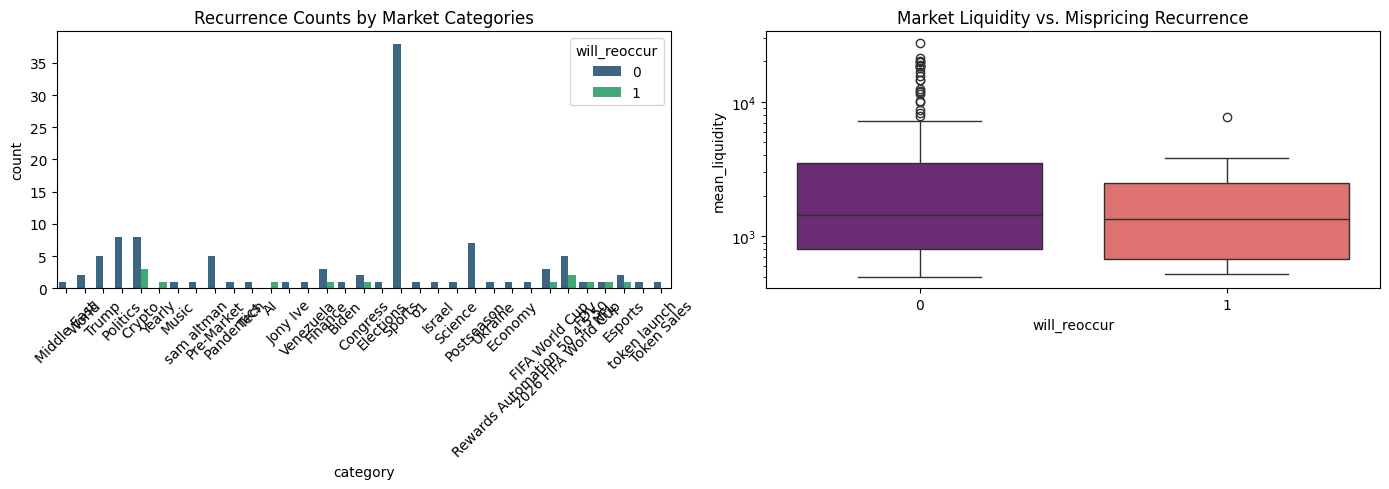

In [4]:
# visualizing characteristics causing reoccurrence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution of market type and reoccurence
sns.countplot(data=market_profiles, x='category', hue='will_reoccur', ax=axes[0], palette='viridis')
axes[0].set_title("Recurrence Counts by Market Categories")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# distribution of liquidity and reoccurrence
sns.boxplot(data=market_profiles, x='will_reoccur', y='mean_liquidity', ax=axes[1], palette='magma')
axes[1].set_yscale('log') # log scale fpr large liquidity variances
axes[1].set_title("Market Liquidity vs. Mispricing Recurrence")

plt.tight_layout()

In [5]:
# imports for modeling and scaling
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

# one-hot encode market categorical fields
X_encoded = pd.get_dummies(X_features, columns=['category'], drop_first=True)

# 80-20 train-test split
# stratify so that train-test splits have the same 7.74% ratio of reoccurence
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_target, test_size=0.2, random_state=1, stratify=y_target)

# scale features bc of wide range of values in cols to help with logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1) logistic regression
lr_model = LogisticRegression(random_state=1, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
# lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_preds = (lr_probs >= 0.35).astype(int)

# 2) random forest classifier
rf_model = RandomForestClassifier(random_state=1, n_estimators=100, class_weight='balanced')
rf_model.fit(X_train, y_train) # random forests don't need scaled inputs bc it uses trees
# rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.25).astype(int)

# 3) keras sequential neural network
tf.random.set_seed(1)

nn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),  
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# compile with binary cross entropy for 2 classes
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

print("Training the Keras Sequential Neural Network...")

# train the network
nn_model.fit(X_train_scaled, y_train, epochs=60, batch_size=16, verbose=0)

# get probabilities and apply custom 15% threshold
nn_probs = nn_model.predict(X_test_scaled, verbose=0).flatten() 
nn_preds = (nn_probs >= 0.15).astype(int)

Training the Keras Sequential Neural Network...


In [6]:
# evaluation report imports
from sklearn.metrics import classification_report, roc_auc_score

# Initialize placeholder baseline models to use for the cross-validation scoring below
cv_lr = LogisticRegression(random_state=1, class_weight='balanced', max_iter=1000)
cv_rf = RandomForestClassifier(random_state=1, n_estimators=100, class_weight='balanced')

# Define the 5-fold stratified splitter to check overall feature strength
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Get cross-validated ROC-AUC scores across the entire dataset
rf_cv_scores = cross_val_score(cv_rf, X_encoded, y_target, cv=cv, scoring='roc_auc')
lr_pipeline = make_pipeline(StandardScaler(), cv_lr) 
lr_cv_scores = cross_val_score(lr_pipeline, X_encoded, y_target, cv=cv, scoring='roc_auc')

print("5-Fold Cross-Validation Baselines")
print(f"Random Forest True Average ROC-AUC: {rf_cv_scores.mean():.2f}")
print(f"Logistic Regression True Average ROC-AUC: {lr_cv_scores.mean():.2f}\n")

# print results for logistic regression
print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_preds))

# print results for random forest
print("RANDOM FOREST")
print(classification_report(y_test, rf_preds))

5-Fold Cross-Validation Baselines
Random Forest True Average ROC-AUC: 0.65
Logistic Regression True Average ROC-AUC: 0.60

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.97      0.56      0.71        55
           1       0.14      0.80      0.24         5

    accuracy                           0.58        60
   macro avg       0.56      0.68      0.48        60
weighted avg       0.90      0.58      0.67        60

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        55
           1       0.40      0.40      0.40         5

    accuracy                           0.90        60
   macro avg       0.67      0.67      0.67        60
weighted avg       0.90      0.90      0.90        60



In [7]:
# print results for keras neural network
print("KERAS SEQUENTIAL NN")
print(classification_report(y_test, nn_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, nn_probs):.4f}\n")

KERAS SEQUENTIAL NN
              precision    recall  f1-score   support

           0       0.92      0.87      0.90        55
           1       0.12      0.20      0.15         5

    accuracy                           0.82        60
   macro avg       0.52      0.54      0.53        60
weighted avg       0.86      0.82      0.84        60

ROC-AUC Score: 0.5200



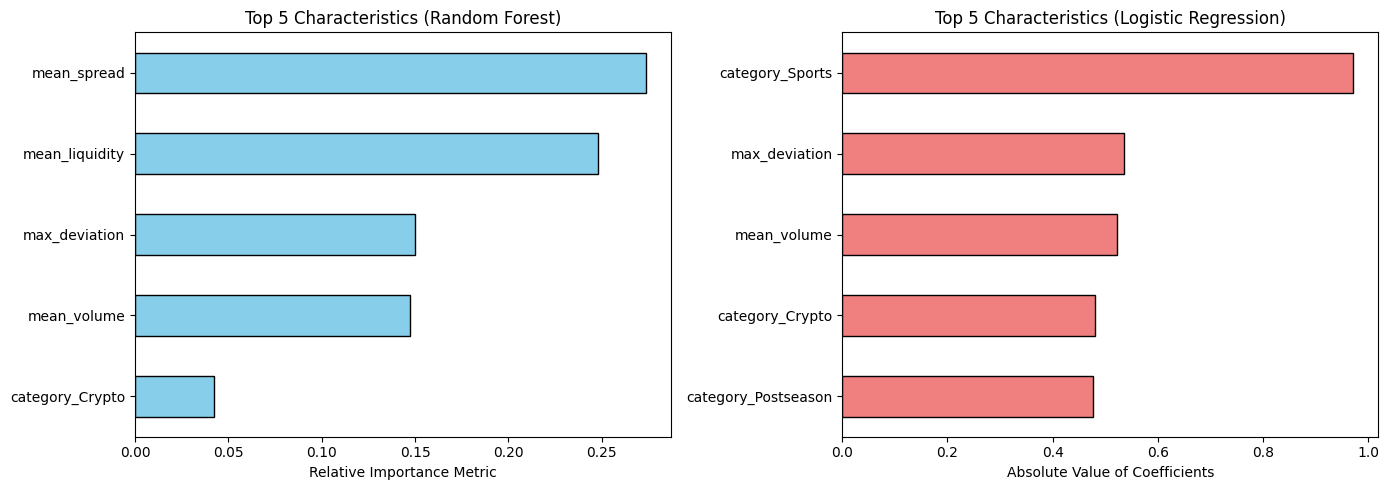

In [8]:
# get random forest feature importances
rf_imp = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
top_rf = rf_imp.nlargest(5)

# get logistic regression coefficients
# take abs value of coeffs bc a strong negative effect
# is as important to the model as a strong positive one
lr_coeffs = np.abs(lr_model.coef_[0])
lr_imp = pd.Series(lr_coeffs, index=X_encoded.columns)
top_lr = lr_imp.nlargest(5)

# create two plot visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# plot random forest relative importance metrics
top_rf.plot(kind='barh', ax=ax1, color='skyblue', edgecolor='black')
ax1.invert_yaxis()  # most important characteristic at the top
ax1.set_title("Top 5 Characteristics (Random Forest)")
ax1.set_xlabel("Relative Importance Metric")

# plot abs value of logistic regression coeffs
top_lr.plot(kind='barh', ax=ax2, color='lightcoral', edgecolor='black')
ax2.invert_yaxis()  # most important characteristic at the top
ax2.set_title("Top 5 Characteristics (Logistic Regression)")
ax2.set_xlabel("Absolute Value of Coefficients")

plt.tight_layout()